# Clasificación de emociones con Transformers
**Procesamiento de Lenguaje Natural · Grupo X-Ray**

## 1. Problema y objetivo
Queremos identificar la emoción expresada en un texto corto en inglés: tristeza (`sadness`), alegría (`joy`), amor (`love`), ira (`anger`), miedo (`fear`) o sorpresa (`surprise`). Usamos el corpus **dair-ai/emotion**, diferente del conjunto de noticias en español del ejemplo de clase.

Esta clasificación puede ayudar a organizar comentarios para su revisión. El reto es que las palabras cambian de sentido según el contexto y algunas emociones se parecen. El corpus asigna una sola etiqueta por texto, aunque una persona podría expresar varias emociones a la vez. El modelo aprende esas etiquetas; no determina el estado psicológico de quien escribe.

Comparamos un **MLP sencillo**, que promedia los vectores de las palabras, con un **encoder Transformer construido desde cero**, que relaciona los tokens mediante atención. Además, seguimos el enfoque del ejemplo con **DistilBERT preentrenado**, primero con su base congelada y después con ajuste fino. Elegimos su versión en inglés porque coincide con el idioma del corpus.

Como aporte adicional, cambiamos la codificación de posición del Transformer y exploramos sus mapas de atención. La pregunta es qué mejora cada alternativa y cuánto tiempo de entrenamiento necesita.

## 2. Preparación y reproducibilidad
Usar Python 3.11 y las versiones de `requirements.txt`. En un entorno nuevo, ejecutar una vez `%pip install -r requirements.txt`, reiniciar el kernel y luego **Run All**. Abrir el notebook desde su carpeta.

La primera ejecución necesita internet para descargar los datos y DistilBERT. El tokenizador de los modelos pequeños se crea aquí con los textos de entrenamiento: no requiere archivos previos. Las revisiones de los datos y del modelo quedan fijas. Las descargas se conservan en la caché de Hugging Face.

Fijamos las semillas y registramos las versiones. Esto facilita repetir los experimentos, aunque otro equipo o dispositivo puede producir pequeñas diferencias numéricas. Los tiempos corresponden al equipo de cada ejecución. Los archivos de trabajo se guardan en `artifacts/` y pueden regenerarse.

In [5]:
# Instalar las dependencias en el entorno que ejecuta este notebook.
%pip install torch==2.8.0 transformers==4.57.6 datasets==4.4.1 tokenizers==0.22.2 accelerate==1.12.0 huggingface-hub==0.36.2 numpy==2.2.6 pandas==2.3.3 matplotlib==3.10.8 seaborn==0.13.2 scikit-learn==1.7.2

Note: you may need to restart the kernel to use updated packages.


In [6]:
import sys
from importlib import import_module
from importlib.metadata import version

paquetes = {
    "torch": "torch",
    "transformers": "transformers",
    "datasets": "datasets",
    "tokenizers": "tokenizers",
    "accelerate": "accelerate",
    "huggingface-hub": "huggingface_hub",
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scikit-learn": "sklearn",
}

print("Python utilizado:", sys.executable)
print()

for paquete, modulo in paquetes.items():
    import_module(modulo)
    print(f"{paquete}: {version(paquete)}")

import torch

dispositivo = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("\nDispositivo disponible:", dispositivo)
print("Las dependencias se importaron correctamente.")

Python utilizado: /Users/edwinandperez/Documents/InfoArbegas/Documents/ICESI/CLASES/SEM III/Procesamiento de Lenguaje Natural/Sesion III/.venv/bin/python

torch: 2.8.0
transformers: 4.57.6
datasets: 4.4.1
tokenizers: 0.22.2
accelerate: 1.12.0
huggingface-hub: 0.36.2
numpy: 2.2.6
pandas: 2.3.3
matplotlib: 3.10.8
seaborn: 0.13.2
scikit-learn: 1.7.2

Dispositivo disponible: mps
Las dependencias se importaron correctamente.


In [7]:
import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')

import copy
import gc
import json
import math
import random
import re
import time
import platform
from pathlib import Path
from collections import Counter
from importlib.metadata import version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from IPython.display import display, Markdown
from datasets import load_dataset, Dataset as HFDataset, DatasetDict
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders
from transformers import (AutoTokenizer, PreTrainedTokenizerFast,
                          AutoModelForSequenceClassification, Trainer, TrainingArguments)

SEED = 42
SEEDS = [42, 43, 44]
EPOCHS_SMALL = 6
EPOCHS_HF = 2
BATCH_SIZE = 64
EMB_DIM = 128
ARTIFACTS = Path('artifacts')
ARTIFACTS.mkdir(exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

set_seed(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.benchmark = False
device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps' if torch.backends.mps.is_available() else 'cpu')
torch.set_num_threads(min(4, os.cpu_count() or 1))
sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', None)

environment = {'Python': platform.python_version(), 'Dispositivo': str(device),
               **{p: version(p) for p in ['torch', 'transformers', 'datasets',
                   'tokenizers', 'accelerate', 'numpy', 'pandas', 'scikit-learn']}}
display(pd.Series(environment, name='Entorno'))
(ARTIFACTS/'entorno.json').write_text(json.dumps(environment, indent=2))

Python          3.11.16
Dispositivo         mps
torch             2.8.0
transformers     4.57.6
datasets          4.4.1
tokenizers       0.22.2
accelerate       1.12.0
numpy             2.2.6
pandas            2.3.3
scikit-learn      1.7.2
Name: Entorno, dtype: object

240

## 3. Datos y revisión de calidad
El corpus viene dividido en entrenamiento, validación y prueba. Entrenamiento sirve para aprender; validación, para elegir la mejor época; prueba se reserva para comparar los modelos al final.

Antes de entrenar revisamos valores faltantes, textos vacíos, etiquetas, duplicados y coincidencias entre las divisiones. Aplicamos una regla fija: dentro de cada división retiramos textos con etiquetas contradictorias y conservamos una copia de los repetidos. Luego retiramos de validación los textos ya presentes en entrenamiento, y de prueba los presentes en cualquiera de las dos divisiones anteriores. La comparación se hace sobre estas mismas divisiones depuradas para todos los modelos.

In [8]:
DATASET_ID = 'dair-ai/emotion'
DATASET_REVISION = 'cab853a1dbdf4c42c2b3ef2173804746df8825fe'
raw = load_dataset(DATASET_ID, 'split', revision=DATASET_REVISION)
id2label = {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
label2id = {v: k for k, v in id2label.items()}
target_names = list(id2label.values())
NUM_CLASSES = len(target_names)

frames, audit_rows = {}, []
for split in ['train', 'validation', 'test']:
    df = raw[split].to_pandas()[['text', 'label']].copy()
    initial = len(df)
    missing = df[['text', 'label']].isna().any(axis=1)
    n_missing = int(missing.sum())
    df = df.loc[~missing].copy()
    df['text'] = df['text'].str.strip()
    empty = df['text'].eq('')
    n_empty = int(empty.sum())
    df = df.loc[~empty].copy()
    assert df['label'].isin(id2label).all(), 'Hay etiquetas fuera de las seis clases.'
    df['key'] = df['text'].str.lower().str.replace(r'\s+', ' ', regex=True)
    conflicts = df.groupby('key')['label'].nunique()
    conflicting_keys = set(conflicts[conflicts > 1].index)
    conflict_mask = df['key'].isin(conflicting_keys)
    n_conflicts = int(conflict_mask.sum())
    df = df.loc[~conflict_mask].copy()
    n_duplicates = int(df['key'].duplicated().sum())
    df = df.drop_duplicates('key').reset_index(drop=True)
    frames[split] = df
    audit_rows.append({'División': split, 'Original': initial, 'Faltantes': n_missing,
                       'Vacíos': n_empty, 'Filas contradictorias': n_conflicts,
                       'Copias repetidas': n_duplicates})

overlap_rows = []
for a, b in [('train', 'validation'), ('train', 'test'), ('validation', 'test')]:
    overlap_rows.append({'Divisiones': f'{a} / {b}',
                         'Textos coincidentes': len(set(frames[a]['key']) & set(frames[b]['key']))})
display(pd.DataFrame(overlap_rows))

seen = set()
for row in audit_rows:
    split = row['División']
    df = frames[split]
    repeated = df['key'].isin(seen)
    row['Coinciden con división anterior'] = int(repeated.sum())
    df = df.loc[~repeated].reset_index(drop=True)
    seen.update(df['key'])
    df['emotion'] = df['label'].map(id2label)
    frames[split] = df
    row['Final'] = len(df)
    assert len(df) > 0 and set(df['label']) == set(id2label)

audit = pd.DataFrame(audit_rows)
display(audit)
train_df, val_df, test_df = (frames[s] for s in ['train', 'validation', 'test'])
audit.to_csv(ARTIFACTS/'revision_datos.csv', index=False)
display(train_df[['text', 'emotion']].head())

,Divisiones,Textos coincidentes
0,train / validation,5
1,train / test,11
2,validation / test,3


,División,Original,Faltantes,Vacíos,Filas contradictorias,Copias repetidas,Coinciden con división anterior,Final
0,train,16000,0,0,60,1,0,15939
1,validation,2000,0,0,4,0,5,1991
2,test,2000,0,0,0,0,14,1986


,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,love
4,i am feeling grouchy,anger


### 3.1 Distribución de clases
Una exactitud alta puede ocultar errores en las clases poco frecuentes. Por eso usamos **Macro F1** como criterio principal: calcula el F1 de cada emoción y les da el mismo peso. También reportamos exactitud y F1 ponderado para completar la comparación.

,train,validation,test,% entrenamiento
emotion,,,,
sadness,4662,550,579,29.25
joy,5345,701,688,33.53
love,1289,174,156,8.09
anger,2152,274,274,13.50
fear,1926,211,224,12.08
surprise,565,81,65,3.54


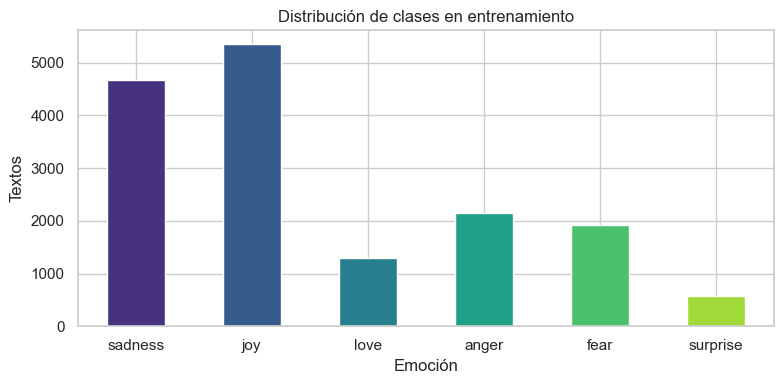

La clase más frecuente es **joy** (33.53 %) y la menos frecuente es **surprise** (3.54 %). Revisaremos las métricas por emoción para ver si la mejora alcanza a las clases pequeñas.

In [9]:
class_summary = pd.DataFrame({s: frames[s]['emotion'].value_counts().reindex(target_names, fill_value=0)
                              for s in frames})
class_summary['% entrenamiento'] = 100 * class_summary['train'] / len(train_df)
display(class_summary.round(2))
ax = class_summary['train'].plot.bar(figsize=(8, 4), color=sns.color_palette('viridis', 6), rot=0)
ax.set(xlabel='Emoción', ylabel='Textos', title='Distribución de clases en entrenamiento')
plt.tight_layout()
plt.show()
largest = class_summary['train'].idxmax()
smallest = class_summary['train'].idxmin()
display(Markdown(f'La clase más frecuente es **{largest}** '
                 f'({class_summary.loc[largest, "% entrenamiento"]:.2f} %) y la menos frecuente es '
                 f'**{smallest}** ({class_summary.loc[smallest, "% entrenamiento"]:.2f} %). '
                 'Revisaremos las métricas por emoción para ver si la mejora alcanza a las clases pequeñas.'))

### 3.2 Longitud y vocabulario
Observamos la longitud de los textos y las palabras frecuentes por emoción. Estos gráficos describen el corpus; no demuestran que una palabra sea exclusiva de una categoría. Más adelante mediremos la longitud con cada tokenizador para elegir el límite de entrada.

,Palabras
count,15939.000000
mean,19.176674
std,10.994633
min,2.000000
50%,17.000000
90%,35.000000
95%,41.000000
99%,52.000000
max,66.000000


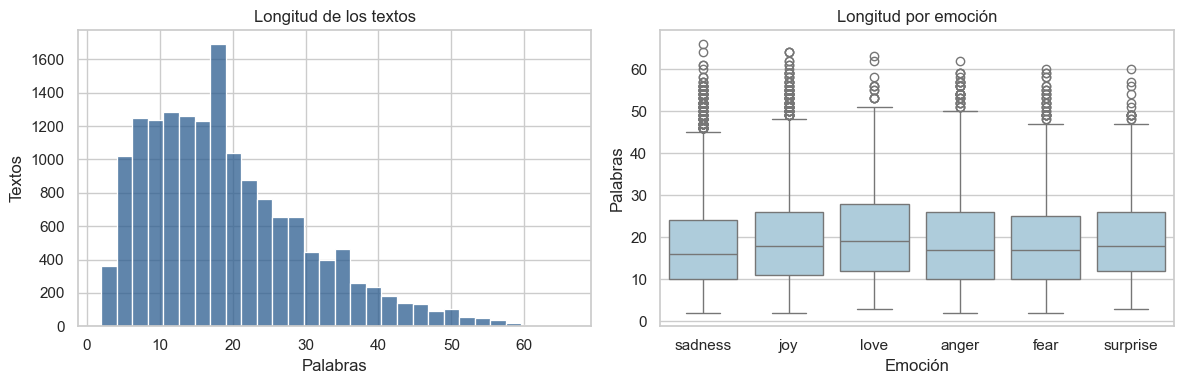

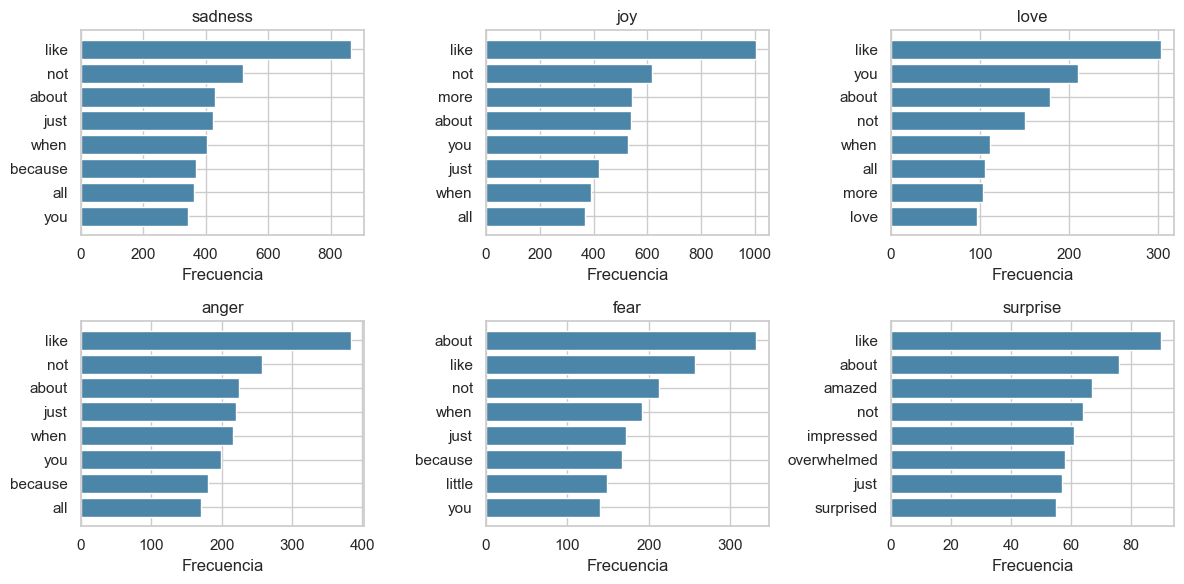

In [10]:
train_df['word_count'] = train_df['text'].str.split().str.len()
display(train_df['word_count'].describe(percentiles=[.5, .9, .95, .99]).to_frame('Palabras'))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_df['word_count'], bins=30, ax=axes[0], color='#2b5c8f')
axes[0].set(xlabel='Palabras', ylabel='Textos', title='Longitud de los textos')
sns.boxplot(data=train_df, x='emotion', y='word_count', order=target_names, ax=axes[1], color='#a6cee3')
axes[1].set(xlabel='Emoción', ylabel='Palabras', title='Longitud por emoción')
plt.tight_layout()
plt.show()

stopwords = set('i feel feeling to and a the that my of in it was for on have with this but at am is me so be'.split())
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for emotion, ax in zip(target_names, axes.flat):
    words = [w for text in train_df.loc[train_df['emotion'] == emotion, 'text']
             for w in re.findall(r'\b[a-z]{3,}\b', text.lower()) if w not in stopwords]
    top = Counter(words).most_common(8)
    ax.barh([w for w, _ in top][::-1], [n for _, n in top][::-1], color='#4b85a8')
    ax.set(title=emotion, xlabel='Frecuencia')
plt.tight_layout()
plt.show()

**Lectura del vocabulario.** Palabras como `like` y `not` aparecen entre las más frecuentes de varias emociones. Su presencia por sí sola no identifica una clase. En sorpresa aparecen términos más específicos como `amazed`, `impressed` y `surprised`. Esto ayuda a entender por qué un modelo sencillo puede aprovechar palabras indicativas, pero también por qué habrá confusiones entre clases.

## 4. Tokenización y longitud de entrada
Entrenamos un tokenizador BPE de hasta 10.000 tokens **solo con entrenamiento**. Divide el texto en fragmentos y asigna un número a cada uno. `[PAD]` rellena las posiciones sobrantes y su máscara evita que participen en la atención y el promedio.

DistilBERT utiliza su propio tokenizador preentrenado, porque sus números deben corresponder a los embeddings que aprendió. No intercambiamos los dos tokenizadores.

In [11]:
backend = Tokenizer(models.BPE(unk_token='[UNK]'))
backend.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
backend.decoder = decoders.ByteLevel()
bpe_trainer = trainers.BpeTrainer(vocab_size=10000, min_frequency=2,
    special_tokens=['[UNK]', '[PAD]'], initial_alphabet=sorted(pre_tokenizers.ByteLevel.alphabet()))
backend.train_from_iterator(train_df['text'].tolist(), trainer=bpe_trainer)
emotion_tokenizer = PreTrainedTokenizerFast(tokenizer_object=backend, unk_token='[UNK]', pad_token='[PAD]')
emotion_tokenizer.save_pretrained(ARTIFACTS/'emotion_tokenizer')
pad_token_id = emotion_tokenizer.pad_token_id
vocab_size = len(emotion_tokenizer)

MODEL_ID = 'distilbert/distilbert-base-uncased'
MODEL_REVISION = '12040accade4e8a0f71eabdb258fecc2e7e948be'
hf_tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, revision=MODEL_REVISION)

def token_lengths(tokenizer, texts):
    return np.array([len(ids) for ids in tokenizer(texts.tolist(), truncation=False,
                                                 padding=False)['input_ids']])

# Elegimos con entrenamiento un límite común que cubra al menos el percentil 99 de ambos tokenizadores.
lengths_bpe = token_lengths(emotion_tokenizer, train_df['text'])
lengths_hf = token_lengths(hf_tokenizer, train_df['text'])
p99 = max(np.quantile(lengths_bpe, .99), np.quantile(lengths_hf, .99))
MAX_LEN = min(512, max(16, int(math.ceil(p99 / 8) * 8)))
length_rows = []
for name, tokenizer in [('BPE propio', emotion_tokenizer), ('DistilBERT', hf_tokenizer)]:
    for split, df in frames.items():
        lengths = token_lengths(tokenizer, df['text'])
        length_rows.append({'Tokenizador': name, 'División': split,
                            'P99 tokens': float(np.quantile(lengths, .99)),
                            'Textos recortados': int((lengths > MAX_LEN).sum()),
                            '% recortado': float(100 * (lengths > MAX_LEN).mean())})
display(pd.DataFrame(length_rows).round(2))
print(f'Vocabulario BPE: {vocab_size:,}. Longitud máxima: {MAX_LEN} tokens.')
sample = emotion_tokenizer('i feel happy today', max_length=16, padding='max_length', truncation=True)
display(pd.DataFrame({'Token': emotion_tokenizer.convert_ids_to_tokens(sample['input_ids']),
                      'ID': sample['input_ids'], 'Máscara': sample['attention_mask']}))

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

,Tokenizador,División,P99 tokens,Textos recortados,% recortado
0,BPE propio,train,55.62,19,0.12
1,BPE propio,validation,58.00,4,0.20
2,BPE propio,test,55.15,1,0.05
3,DistilBERT,train,57.00,25,0.16
4,DistilBERT,validation,56.00,2,0.10
5,DistilBERT,test,55.00,3,0.15


Vocabulario BPE: 10,000. Longitud máxima: 64 tokens.


,Token,ID,Máscara
0,i,74,1
1,Ġfeel,268,1
2,Ġhappy,761,1
3,Ġtoday,668,1
4,[PAD],1,0
5,[PAD],1,0
6,[PAD],1,0
7,[PAD],1,0
8,[PAD],1,0
9,[PAD],1,0


**Decisión sobre la longitud.** Con 64 tokens se recorta menos del 0,2 % de los textos de entrenamiento con cada tokenizador. El límite permite conservar completos casi todos los textos sin añadir demasiado relleno. La tabla también muestra el recorte en validación y prueba; esas divisiones no se usaron para elegir el límite.

## 5. Modelos desde cero
### 5.1 MLP de referencia
El MLP aprende un vector por token y promedia los tokens reales del texto. Después aplica capas densas para elegir una emoción. Es una referencia sencilla que permite comprobar si la atención aporta una mejora. Al promediar, pierde el orden de los tokens.

In [13]:
class SimpleMLPClassifier(nn.Module):
    """Modelo de línea base simple de tipo MLP sobre embeddings promediados."""
    def __init__(self, vocab_size: int, emb_dim: int, num_classes: int, pad_idx: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, input_ids, attention_mask=None):
        embeds = self.embedding(input_ids)  # (Batch, Seq_Len, Emb_Dim)
        if attention_mask is not None:
            mask = attention_mask.unsqueeze(-1).float()
            pooled = (embeds * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        else:
            pooled = embeds.mean(dim=1)
        return self.mlp(pooled)

### 5.2 Posición y atención
La atención relaciona tokens, pero necesita información adicional para distinguir sus posiciones. Probamos dos opciones: una codificación sinusoidal fija y una tabla de posiciones que se aprende durante el entrenamiento.

Para cada cabeza calculamos:
$$\mathrm{Attention}(Q,K,V)=\mathrm{softmax}\left(\frac{QK^T}{\sqrt{d_k}}+M\right)V$$
`Q`, `K` y `V` son proyecciones de los embeddings. La máscara `M` excluye las claves correspondientes al relleno. Cada cabeza puede aprender relaciones distintas; eso se debe comprobar en los resultados y no se da por hecho.

In [14]:
class SinusoidPE(nn.Module):
    """Positional Encoding sinusoidal precalculado (Vaswani et al., 2017)."""
    def __init__(self, max_len: int, d_model: int):
        super().__init__()
        pos = torch.arange(max_len).unsqueeze(1)
        i = torch.arange(d_model).unsqueeze(0)
        div_term = 1 / torch.pow(10000.0, (2 * (i // 2)) / float(d_model))
        angle_rads = pos * div_term

        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = torch.cos(angle_rads[:, 1::2])

        self.register_buffer('pos_encoding', pe.unsqueeze(0), persistent=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Sumar el vector de posición a la secuencia de embeddings de tokens
        return x + self.pos_encoding[:, :x.size(1), :]

class LearnablePE(nn.Module):
    """Positional Encoding basado en embeddings aprendibles por gradiente."""
    def __init__(self, max_len: int, d_model: int):
        super().__init__()
        self.pos_embedding = nn.Embedding(max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        seq_len = x.size(1)
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0)
        return x + self.pos_embedding(positions)

In [15]:
class MultiHeadAttention(nn.Module):
    """Mecanismo de atención multi-cabeza (Scaled Dot-Product Multi-Head Attention)."""
    def __init__(self, embed_size: int, num_heads: int = 4, dropout: float = 0.1):
        super().__init__()
        self.embed_size = embed_size
        self.num_heads = num_heads
        assert embed_size % num_heads == 0, "El tamaño del embedding debe ser divisible por el número de cabezas."
        self.head_dim = embed_size // num_heads

        # Proyecciones lineales para Query, Key, Value y salida
        self.q_proj = nn.Linear(embed_size, embed_size)
        self.k_proj = nn.Linear(embed_size, embed_size)
        self.v_proj = nn.Linear(embed_size, embed_size)
        self.out_proj = nn.Linear(embed_size, embed_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None, return_attention=False):
        batch_size, seq_len, _ = x.size()

        # Proyectar y separar en h cabezas: (Batch, Num_Heads, Seq_Len, Head_Dim)
        q = self.q_proj(x).reshape(batch_size, seq_len, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        k = self.k_proj(x).reshape(batch_size, seq_len, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        v = self.v_proj(x).reshape(batch_size, seq_len, self.num_heads, self.head_dim).permute(0, 2, 1, 3)

        # Scaled Dot-Product: Q * K^T / sqrt(d_k)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        # Aplicar máscara para ignorar tokens de relleno
        if mask is not None:
            # mask: (Batch, Seq_Len) -> (Batch, 1, 1, Seq_Len)
            scores = scores.masked_fill(mask.unsqueeze(1).unsqueeze(2) == 0, -1e9)

        # Softmax a lo largo de las claves
        attn_weights = torch.softmax(scores, dim=-1)
        attn_weights_dropped = self.dropout(attn_weights)

        # Multiplicar pesos por los Valores: Attention(Q,K,V) = Softmax(...) * V
        context = torch.matmul(attn_weights_dropped, v)

        # Re-combinar y concatenar cabezas
        context = context.permute(0, 2, 1, 3).reshape(batch_size, seq_len, self.embed_size)
        output = self.out_proj(context)

        if return_attention:
            return output, attn_weights
        return output

### 5.3 Encoder y clasificador
Implementamos los componentes del encoder original: atención multicanal, conexiones residuales, normalización **después** de cada suma y una red densa con **ReLU**. Escalamos los embeddings antes de sumar la posición.

Usamos una versión pequeña, con dos bloques, cuatro cabezas y embeddings de 128 dimensiones. Es una adaptación del encoder para clasificación, no una reproducción del modelo completo de traducción: no necesitamos decoder porque la salida es una etiqueta. Promediamos los tokens válidos y añadimos un clasificador. Este promedio evita una capa de salida cuyo tamaño dependa de la longitud del texto.

In [16]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, emb_dim, num_heads=4, ffn_dim=512, dropout=.1):
        super().__init__()
        self.mha = MultiHeadAttention(emb_dim, num_heads, dropout)
        self.norm1 = nn.LayerNorm(emb_dim)
        self.norm2 = nn.LayerNorm(emb_dim)
        self.ffn = nn.Sequential(nn.Linear(emb_dim, ffn_dim), nn.ReLU(), nn.Linear(ffn_dim, emb_dim))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None, return_attention=False):
        if return_attention:
            attn_out, weights = self.mha(x, mask, return_attention=True)
        else:
            attn_out = self.mha(x, mask)
        x = self.norm1(x + self.dropout(attn_out))
        x = self.norm2(x + self.dropout(self.ffn(x)))
        return (x, weights) if return_attention else x

class TransformerClassifier(nn.Module):
    def __init__(self, pos_type='sinusoid'):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, EMB_DIM, padding_idx=pad_token_id)
        self.pos_enc = SinusoidPE(MAX_LEN, EMB_DIM) if pos_type == 'sinusoid' else LearnablePE(MAX_LEN, EMB_DIM)
        self.input_dropout = nn.Dropout(.1)
        self.layers = nn.ModuleList([TransformerEncoderBlock(EMB_DIM) for _ in range(2)])
        self.classifier = nn.Sequential(nn.Linear(EMB_DIM, 128), nn.ReLU(), nn.Dropout(.2), nn.Linear(128, NUM_CLASSES))

    def forward(self, input_ids, attention_mask=None, return_attention=False):
        x = self.input_dropout(self.pos_enc(self.token_emb(input_ids) * math.sqrt(EMB_DIM)))
        attentions = []
        for layer in self.layers:
            if return_attention:
                x, attn = layer(x, attention_mask, True)
                attentions.append(attn)
            else:
                x = layer(x, attention_mask)
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (x * mask).sum(1) / mask.sum(1).clamp(min=1)
        logits = self.classifier(pooled)
        return (logits, attentions) if return_attention else logits

## 6. Entrenamiento y selección con validación
Los tres modelos pequeños usan los mismos datos, tokenizador, tamaño de lote y seis épocas. El MLP utiliza una tasa de aprendizaje de 0,002 y los Transformers de 0,0005. Son configuraciones fijadas antes de evaluar prueba; no pretendemos aislar únicamente el efecto de la arquitectura al comparar MLP y Transformer.

Para comparar las posiciones sinusoidales y aprendibles sí mantenemos la misma configuración y los mismos pesos iniciales en los componentes compartidos. Repetimos los tres modelos con las semillas 42, 43 y 44, y presentamos la variación en validación. Para prueba utilizamos la semilla 42, elegida de antemano, sin seleccionar la semilla más favorable.

Guardamos la época con mejor Macro F1 de validación. El conjunto de prueba no se usa para escoger épocas o configuraciones.

In [17]:
class EmotionDataset(Dataset):
    def __init__(self, df, tokenizer):
        self.encoding = tokenizer(df['text'].tolist(), max_length=MAX_LEN,
                                  padding='max_length', truncation=True, return_tensors='pt')
        self.labels = torch.tensor(df['label'].to_numpy(), dtype=torch.long)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        return {'input_ids': self.encoding['input_ids'][i],
                'attention_mask': self.encoding['attention_mask'][i], 'labels': self.labels[i]}

small_ds = {s: EmotionDataset(df, emotion_tokenizer) for s, df in frames.items()}
def make_loader(split, seed=SEED):
    return DataLoader(small_ds[split], batch_size=BATCH_SIZE, shuffle=(split == 'train'),
                      generator=torch.Generator().manual_seed(seed), num_workers=0,
                      drop_last=(split == 'train' and len(small_ds[split]) % BATCH_SIZE == 1))

def synchronize():
    if device.type == 'cuda': torch.cuda.synchronize()
    elif device.type == 'mps': torch.mps.synchronize()

def release_memory():
    gc.collect()
    if device.type == 'mps': torch.mps.empty_cache()
    elif device.type == 'cuda': torch.cuda.empty_cache()

def evaluate_small(model, loader):
    model.eval()
    preds, labels, total_loss = [], [], 0.
    with torch.no_grad():
        for batch in loader:
            x, mask, y = (batch[k].to(device) for k in ['input_ids', 'attention_mask', 'labels'])
            logits = model(x, mask)
            total_loss += nn.functional.cross_entropy(logits, y, reduction='sum').item()
            preds.extend(logits.argmax(-1).cpu().tolist())
            labels.extend(y.cpu().tolist())
    return {'loss': total_loss / len(labels), 'accuracy': accuracy_score(labels, preds),
            'f1_macro': f1_score(labels, preds, labels=list(id2label), average='macro', zero_division=0),
            'preds': preds, 'labels': labels}

def train_small(model, name, seed, lr):
    set_seed(seed)
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    train_loader, val_loader = make_loader('train', seed), make_loader('validation')
    best_score, best_state, best_epoch = -1., None, None
    history = []
    synchronize()
    start = time.perf_counter()
    for epoch in range(1, EPOCHS_SMALL + 1):
        model.train()
        total_loss, correct, total = 0., 0, 0
        for batch in train_loader:
            x, mask, y = (batch[k].to(device) for k in ['input_ids', 'attention_mask', 'labels'])
            optimizer.zero_grad(set_to_none=True)
            logits = model(x, mask)
            loss = nn.functional.cross_entropy(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.)
            optimizer.step()
            total_loss += loss.item() * len(y)
            correct += (logits.argmax(-1) == y).sum().item()
            total += len(y)
        val = evaluate_small(model, val_loader)
        history.append({'epoch': epoch, 'train_loss': total_loss / total,
                        'train_acc': correct / total, 'val_loss': val['loss'],
                        'val_acc': val['accuracy'], 'val_f1': val['f1_macro']})
        if val['f1_macro'] > best_score:
            best_score, best_epoch = val['f1_macro'], epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f'{name} · semilla {seed} · época {epoch}: Macro F1 validación = {val["f1_macro"]:.4f}', flush=True)
    synchronize()
    duration = time.perf_counter() - start
    model.load_state_dict(best_state)
    torch.save(best_state, ARTIFACTS/f'{name}_{seed}.pt')
    model.cpu()
    del optimizer
    release_memory()
    return model, history, {'Modelo': name, 'Semilla': seed, 'Mejor época': best_epoch,
                           'Macro F1 validación': best_score, 'Tiempo entrenamiento (s)': duration,
                           'Parámetros totales': sum(p.numel() for p in model.parameters()),
                           'Parámetros entrenables': sum(p.numel() for p in model.parameters() if p.requires_grad)}

small_models, histories, runs = {}, {}, []
for seed in SEEDS:
    set_seed(seed)
    mlp = SimpleMLPClassifier(vocab_size, EMB_DIM, NUM_CLASSES, pad_token_id)
    set_seed(seed)
    sinusoid = TransformerClassifier('sinusoid')
    learned = TransformerClassifier('learnable')
    # Ambas variantes empiezan con los mismos pesos, salvo las posiciones aprendibles.
    shared = {k: v for k, v in sinusoid.state_dict().items() if k in learned.state_dict()}
    learned.load_state_dict(shared, strict=False)
    for name, model, lr in [('MLP', mlp, 2e-3), ('Transformer sinusoidal', sinusoid, 5e-4),
                            ('Transformer posiciones aprendibles', learned, 5e-4)]:
        model, history, record = train_small(model, name, seed, lr)
        runs.append(record)
        if seed == SEED:
            small_models[name], histories[name] = model, pd.DataFrame(history)
    del mlp, sinusoid, learned, model
    release_memory()

runs_df = pd.DataFrame(runs)
runs_df.to_csv(ARTIFACTS/'experimentos_validacion.csv', index=False)
display(runs_df.round(4))
validation_summary = runs_df.groupby('Modelo')['Macro F1 validación'].agg(['mean', 'std', 'min', 'max'])
display(validation_summary.rename(columns={'mean': 'Media', 'std': 'Desviación', 'min': 'Mínimo', 'max': 'Máximo'}).round(4))

MLP · semilla 42 · época 1: Macro F1 validación = 0.3480
MLP · semilla 42 · época 2: Macro F1 validación = 0.6000
MLP · semilla 42 · época 3: Macro F1 validación = 0.7014
MLP · semilla 42 · época 4: Macro F1 validación = 0.7241
MLP · semilla 42 · época 5: Macro F1 validación = 0.7457
MLP · semilla 42 · época 6: Macro F1 validación = 0.7481
Transformer sinusoidal · semilla 42 · época 1: Macro F1 validación = 0.2345
Transformer sinusoidal · semilla 42 · época 2: Macro F1 validación = 0.6146
Transformer sinusoidal · semilla 42 · época 3: Macro F1 validación = 0.8077
Transformer sinusoidal · semilla 42 · época 4: Macro F1 validación = 0.8296
Transformer sinusoidal · semilla 42 · época 5: Macro F1 validación = 0.8494
Transformer sinusoidal · semilla 42 · época 6: Macro F1 validación = 0.8468
Transformer posiciones aprendibles · semilla 42 · época 1: Macro F1 validación = 0.2350
Transformer posiciones aprendibles · semilla 42 · época 2: Macro F1 validación = 0.6401
Transformer posiciones apr

,Modelo,Semilla,Mejor época,Macro F1 validación,Tiempo entrenamiento (s),Parámetros totales,Parámetros entrenables
0,MLP,42,6,0.7481,15.3054,1347462,1347462
1,Transformer sinusoidal,42,5,0.8494,39.5815,1693830,1693830
2,Transformer posiciones aprendibles,42,5,0.8443,38.9142,1702022,1702022
3,MLP,43,6,0.7417,9.6591,1347462,1347462
4,Transformer sinusoidal,43,6,0.8496,60.8521,1693830,1693830
5,Transformer posiciones aprendibles,43,6,0.8613,61.6466,1702022,1702022
6,MLP,44,6,0.7441,13.2328,1347462,1347462
7,Transformer sinusoidal,44,5,0.8585,66.8650,1693830,1693830
8,Transformer posiciones aprendibles,44,6,0.8563,60.0540,1702022,1702022


,Media,Desviación,Mínimo,Máximo
Modelo,,,,
MLP,0.7446,0.0032,0.7417,0.7481
Transformer posiciones aprendibles,0.8540,0.0087,0.8443,0.8613
Transformer sinusoidal,0.8525,0.0052,0.8494,0.8585


### 6.1 Curvas de aprendizaje
Mostramos la semilla fijada para la comparación final. Una pérdida de entrenamiento que baja mientras la de validación sube es una señal de sobreajuste. La línea vertical marca la época seleccionada por Macro F1, que no tiene por qué coincidir con la última.

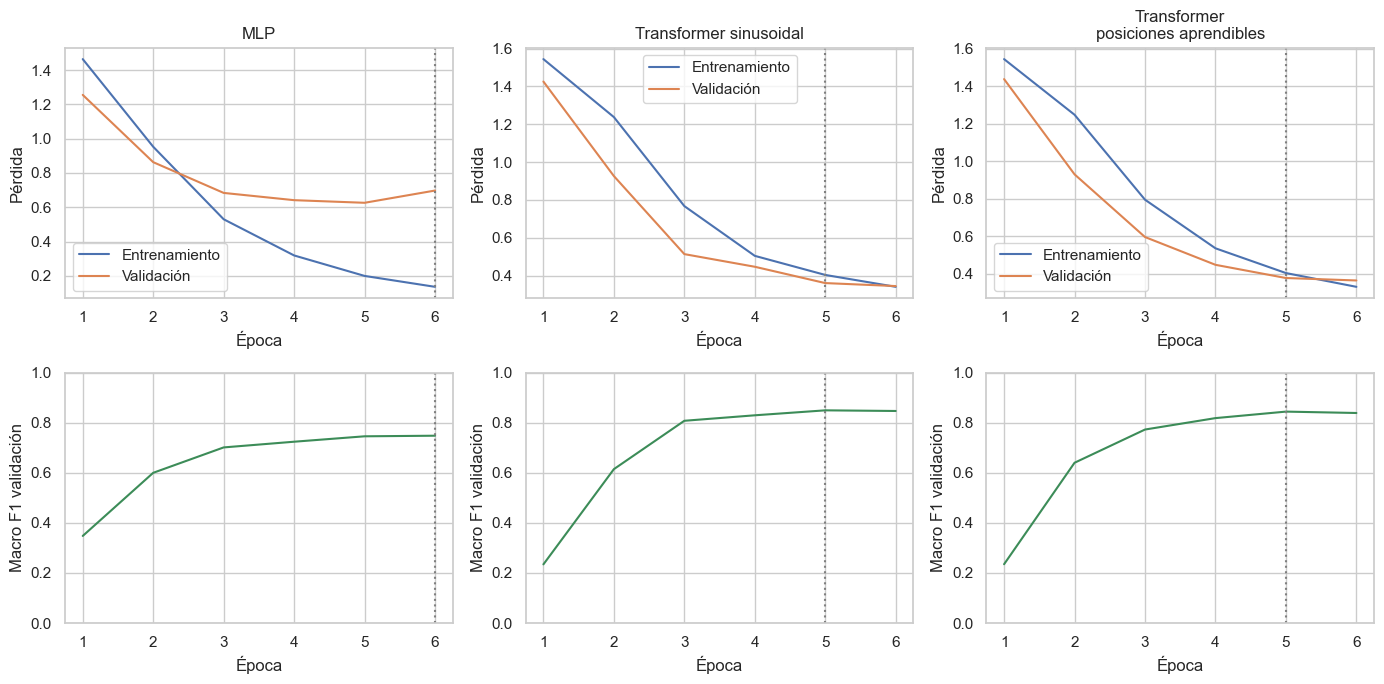

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for i, (name, history) in enumerate(histories.items()):
    best_epoch = int(runs_df.query('Modelo == @name and Semilla == @SEED')['Mejor época'].iloc[0])
    axes[0, i].plot(history['epoch'], history['train_loss'], label='Entrenamiento')
    axes[0, i].plot(history['epoch'], history['val_loss'], label='Validación')
    axes[0, i].axvline(best_epoch, color='gray', linestyle=':')
    axes[0, i].set(title=name.replace(' posiciones ', '\nposiciones '), ylabel='Pérdida', xlabel='Época')
    axes[0, i].legend()
    axes[1, i].plot(history['epoch'], history['val_f1'], color='#3c8c58')
    axes[1, i].axvline(best_epoch, color='gray', linestyle=':')
    axes[1, i].set(ylabel='Macro F1 validación', xlabel='Época', ylim=(0, 1))
plt.tight_layout()
plt.show()

**Lectura de las curvas.** En esta ejecución, con la semilla 42, el mejor Macro F1 de validación se obtuvo en la época 6 para el MLP y en la época 5 para los dos Transformers. Por eso conservamos esas versiones para evaluar en prueba. La selección se basa en Macro F1 de validación, no necesariamente en la menor pérdida ni en la última época. Al comparar las tres semillas, las posiciones sinusoidales y aprendibles intercambian el orden de sus resultados y sus medias son cercanas. Estos experimentos no muestran una ventaja consistente de una opción sobre la otra.

## 7. Modelo preentrenado, siguiendo el ejemplo de clase
Usamos **DistilBERT en inglés**, una versión más pequeña de la familia BERT. Seguimos los dos pasos del ejemplo: entrenar el clasificador manteniendo congelada la base y ajustar después todas las capas. Cada experimento parte del mismo modelo preentrenado, no del resultado del experimento anterior.

Utilizamos `AutoModelForSequenceClassification` y `Trainer` de Hugging Face. La cabeza de clasificación se inicializa para nuestras seis emociones; el aviso sobre sus pesos nuevos es esperado. En la primera modalidad congelamos la base y la mantenemos en modo evaluación para que sus representaciones no cambien por dropout.

Ambas modalidades usan dos épocas y lotes de 32. La tasa de aprendizaje es 0,001 para la cabeza congelando la base y 0,00002 para el ajuste fino, donde cambios grandes podrían alterar los pesos preentrenados. Esta comparación incluye el efecto del preentrenamiento y de distintas configuraciones, no solo el tamaño del modelo.

In [19]:
hf_datasets = DatasetDict({s: HFDataset.from_pandas(df[['text', 'label']], preserve_index=False)
                           for s, df in frames.items()})
def hf_encode(batch):
    return hf_tokenizer(batch['text'], padding='max_length', truncation=True, max_length=MAX_LEN)
hf_datasets = hf_datasets.map(hf_encode, batched=True, remove_columns=['text'])
hf_datasets = hf_datasets.rename_column('label', 'labels')

def hf_metrics(prediction):
    preds = np.argmax(prediction.predictions, axis=-1)
    return {'accuracy': accuracy_score(prediction.label_ids, preds),
            'f1_macro': f1_score(prediction.label_ids, preds, labels=list(id2label),
                                  average='macro', zero_division=0)}

class FrozenBaseTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        model.base_model.eval()
        return super().compute_loss(model, inputs, return_outputs=return_outputs,
                                    num_items_in_batch=num_items_in_batch)

hf_records, hf_paths, hf_histories = {}, {}, {}
for name, frozen, lr, folder in [('DistilBERT base congelada', True, 1e-3, 'hf_frozen'),
                                  ('DistilBERT ajuste fino', False, 2e-5, 'hf_finetuned')]:
    set_seed(SEED)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_ID, revision=MODEL_REVISION, num_labels=NUM_CLASSES,
        id2label=id2label, label2id=label2id, attn_implementation='eager')
    if frozen:
        for parameter in model.base_model.parameters():
            parameter.requires_grad = False
    counts = {'Parámetros totales': sum(p.numel() for p in model.parameters()),
              'Parámetros entrenables': sum(p.numel() for p in model.parameters() if p.requires_grad)}
    args = TrainingArguments(
        output_dir=str(ARTIFACTS/folder), num_train_epochs=EPOCHS_HF,
        per_device_train_batch_size=32, per_device_eval_batch_size=32,
        learning_rate=lr, weight_decay=.01, warmup_ratio=.1,
        eval_strategy='epoch', save_strategy='epoch', logging_strategy='epoch',
        load_best_model_at_end=True, metric_for_best_model='f1_macro', greater_is_better=True,
        save_total_limit=1, save_only_model=True, report_to='none',
        seed=SEED, data_seed=SEED, dataloader_num_workers=0, dataloader_pin_memory=False,
        disable_tqdm=True, optim='adamw_torch', use_cpu=(device.type == 'cpu'))
    trainer_class = FrozenBaseTrainer if frozen else Trainer
    trainer = trainer_class(model=model, args=args, train_dataset=hf_datasets['train'],
                             eval_dataset=hf_datasets['validation'], compute_metrics=hf_metrics,
                             processing_class=hf_tokenizer)
    synchronize()
    start = time.perf_counter()
    trainer.train()
    synchronize()
    duration = time.perf_counter() - start
    evaluations = [row for row in trainer.state.log_history if 'eval_f1_macro' in row]
    best_log = max(evaluations, key=lambda row: row['eval_f1_macro'])
    hf_records[name] = {'Modelo': name, 'Semilla': SEED, 'Mejor época': best_log['epoch'],
                        'Macro F1 validación': best_log['eval_f1_macro'],
                        'Tiempo entrenamiento (s)': duration, **counts}
    hf_paths[name] = trainer.state.best_model_checkpoint
    hf_histories[name] = trainer.state.log_history
    print(f'{name}: mejor Macro F1 de validación = {best_log["eval_f1_macro"]:.4f}')
    del trainer, model
    release_memory()

display(pd.DataFrame(hf_records.values()).round(4))

Map:   0%|          | 0/15939 [00:00<?, ? examples/s]

Map:   0%|          | 0/1991 [00:00<?, ? examples/s]

Map:   0%|          | 0/1986 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{'loss': 1.3006, 'grad_norm': 5.575994968414307, 'learning_rate': 0.0005567928730512249, 'epoch': 1.0}
{'eval_loss': 1.1748464107513428, 'eval_accuracy': 0.5796082370668006, 'eval_f1_macro': 0.35260355802653015, 'eval_runtime': 6.1181, 'eval_samples_per_second': 325.428, 'eval_steps_per_second': 10.297, 'epoch': 1.0}
{'loss': 1.1205, 'grad_norm': 6.140039920806885, 'learning_rate': 1.1135857461024499e-06, 'epoch': 2.0}
{'eval_loss': 1.0959773063659668, 'eval_accuracy': 0.5911602209944752, 'eval_f1_macro': 0.40751782439368034, 'eval_runtime': 14.1278, 'eval_samples_per_second': 140.928, 'eval_steps_per_second': 4.459, 'epoch': 2.0}
{'train_runtime': 154.0969, 'train_samples_per_second': 206.87, 'train_steps_per_second': 6.476, 'train_loss': 1.2105419334763277, 'epoch': 2.0}
DistilBERT base congelada: mejor Macro F1 de validación = 0.4075


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{'loss': 0.701, 'grad_norm': 1.427688717842102, 'learning_rate': 1.1135857461024499e-05, 'epoch': 1.0}
{'eval_loss': 0.21750615537166595, 'eval_accuracy': 0.9236564540431944, 'eval_f1_macro': 0.8937151850903741, 'eval_runtime': 11.3714, 'eval_samples_per_second': 175.089, 'eval_steps_per_second': 5.54, 'epoch': 1.0}
{'loss': 0.1687, 'grad_norm': 1.4163340330123901, 'learning_rate': 2.2271714922048998e-08, 'epoch': 2.0}
{'eval_loss': 0.167543426156044, 'eval_accuracy': 0.9357106981416373, 'eval_f1_macro': 0.9095898134285303, 'eval_runtime': 12.6248, 'eval_samples_per_second': 157.706, 'eval_steps_per_second': 4.99, 'epoch': 2.0}
{'train_runtime': 708.5107, 'train_samples_per_second': 44.993, 'train_steps_per_second': 1.409, 'train_loss': 0.43481563805100437, 'epoch': 2.0}
DistilBERT ajuste fino: mejor Macro F1 de validación = 0.9096


,Modelo,Semilla,Mejor época,Macro F1 validación,Tiempo entrenamiento (s),Parámetros totales,Parámetros entrenables
0,DistilBERT base congelada,42,2.0,0.4075,154.1608,66958086,595206
1,DistilBERT ajuste fino,42,2.0,0.9096,708.6474,66958086,66958086


## 8. Evaluación final en prueba
Ahora evaluamos las versiones seleccionadas por validación. Todos reciben los mismos textos de prueba. Reportamos Macro F1, exactitud, F1 ponderado, parámetros y tiempo de entrenamiento. Los modelos preentrenados aportan conocimiento de otros corpus, por lo que esta tabla compara alternativas prácticas y no un experimento con recursos idénticos.

El mejor modelo para la demo se elige por validación antes de consultar la tabla de prueba. No usamos esta tabla para volver a ajustar los modelos.

Modelo elegido por validación: DistilBERT ajuste fino


,Exactitud prueba,Macro F1 prueba,F1 ponderado prueba,Macro F1 validación,Mejor época,Parámetros totales,Parámetros entrenables,Tiempo entrenamiento (s)
Modelo,,,,,,,,
MLP,0.8011,0.7288,0.7992,0.7481,6.0,1347462,1347462,15.3054
Transformer sinusoidal,0.8600,0.8236,0.8619,0.8494,5.0,1693830,1693830,39.5815
Transformer posiciones aprendibles,0.8595,0.8189,0.8601,0.8443,5.0,1702022,1702022,38.9142
DistilBERT base congelada,0.5886,0.4044,0.5523,0.4075,2.0,66958086,595206,154.1608
DistilBERT ajuste fino,0.9235,0.8801,0.9236,0.9096,2.0,66958086,66958086,708.6474


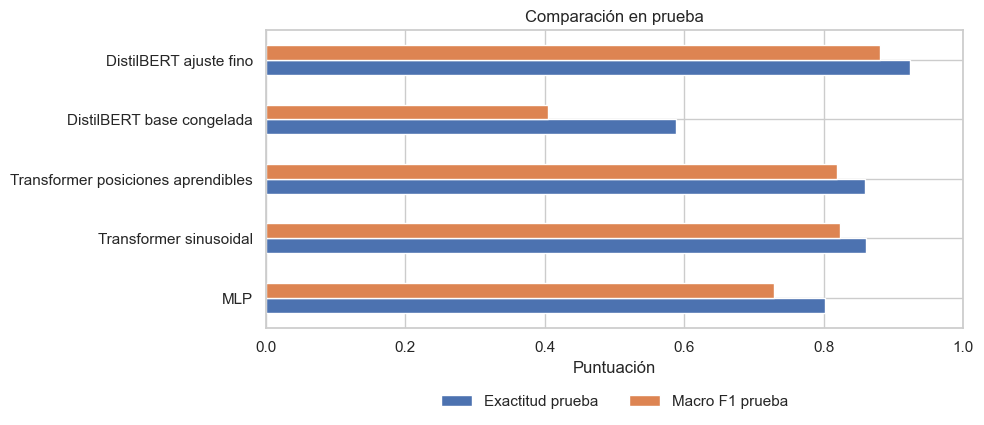

In [20]:
records = {row['Modelo']: row.to_dict() for _, row in runs_df[runs_df['Semilla'] == SEED].iterrows()}
records.update(hf_records)
selected_name = max(records, key=lambda name: records[name]['Macro F1 validación'])
print('Modelo elegido por validación:', selected_name)

predictions, comparison_rows = {}, []
for name, model in small_models.items():
    model.to(device)
    result = evaluate_small(model, make_loader('test'))
    predictions[name] = np.array(result['preds'])
    model.cpu()
    release_memory()

hf_test_ds = EmotionDataset(test_df, hf_tokenizer)
for name, path in hf_paths.items():
    model = AutoModelForSequenceClassification.from_pretrained(path).to(device).eval()
    preds = []
    with torch.no_grad():
        for batch in DataLoader(hf_test_ds, batch_size=32):
            inputs = {k: batch[k].to(device) for k in ['input_ids', 'attention_mask']}
            preds.extend(model(**inputs).logits.argmax(-1).cpu().tolist())
    predictions[name] = np.array(preds)
    del model
    release_memory()

y_test = test_df['label'].to_numpy()
for name, preds in predictions.items():
    assert len(preds) == len(y_test)
    comparison_rows.append({**records[name], 'Exactitud prueba': accuracy_score(y_test, preds),
        'Macro F1 prueba': f1_score(y_test, preds, labels=list(id2label), average='macro', zero_division=0),
        'F1 ponderado prueba': f1_score(y_test, preds, labels=list(id2label), average='weighted', zero_division=0)})
comparison = pd.DataFrame(comparison_rows).set_index('Modelo')
display(comparison[['Exactitud prueba', 'Macro F1 prueba', 'F1 ponderado prueba',
                    'Macro F1 validación', 'Mejor época', 'Parámetros totales',
                    'Parámetros entrenables', 'Tiempo entrenamiento (s)']].round(4))
comparison.to_csv(ARTIFACTS/'comparacion_final.csv')
pd.DataFrame(predictions).assign(label=y_test).to_csv(ARTIFACTS/'predicciones_prueba.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 4.5))
comparison[['Exactitud prueba', 'Macro F1 prueba']].plot.barh(ax=ax)
ax.set(xlim=(0, 1), xlabel='Puntuación', ylabel='', title='Comparación en prueba')
ax.legend(loc='upper center', bbox_to_anchor=(.5, -.18), ncol=2, frameon=False)
plt.tight_layout()
plt.show()

### 8.1 Resultados por emoción
Las matrices normalizadas muestran qué proporción de cada clase se predice correctamente y con qué emociones se confunde. Los reportes incluyen el número de textos evaluados en cada clase para no interpretar igual una clase grande y una pequeña.

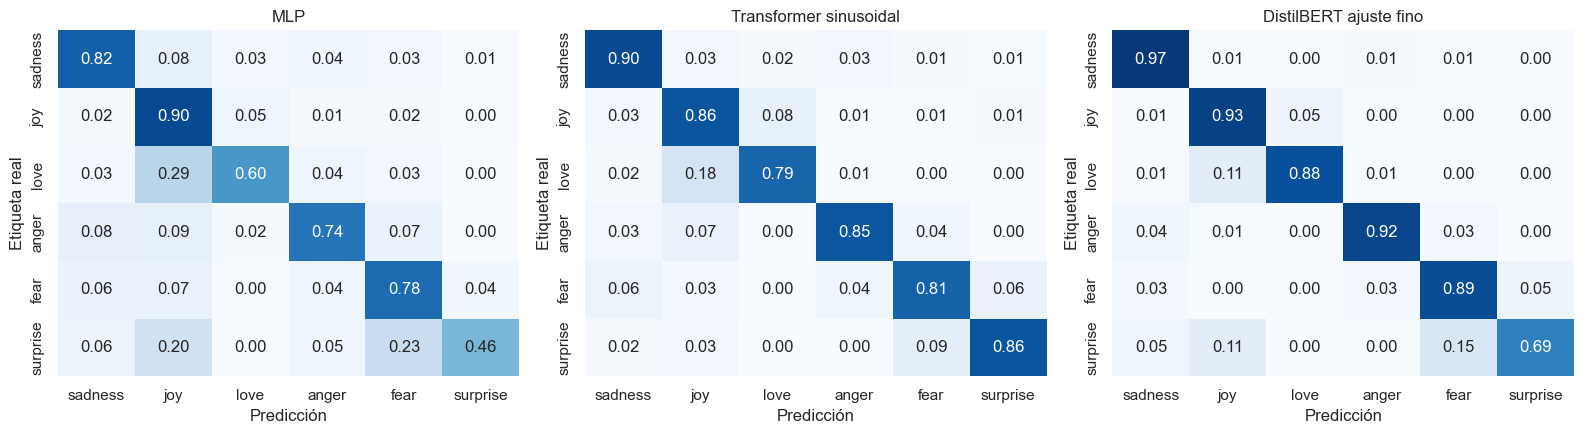

**MLP**

,precision,recall,f1-score,support
sadness,0.891,0.815,0.851,579.0
joy,0.809,0.900,0.852,688.0
love,0.639,0.603,0.620,156.0
anger,0.798,0.737,0.767,274.0
fear,0.710,0.777,0.742,224.0
surprise,0.652,0.462,0.541,65.0


**Transformer sinusoidal**

,precision,recall,f1-score,support
sadness,0.917,0.902,0.909,579.0
joy,0.891,0.859,0.875,688.0
love,0.660,0.795,0.721,156.0
anger,0.867,0.854,0.860,274.0
fear,0.862,0.808,0.834,224.0
surprise,0.651,0.862,0.742,65.0


**Transformer posiciones aprendibles**

,precision,recall,f1-score,support
sadness,0.925,0.922,0.924,579.0
joy,0.890,0.856,0.873,688.0
love,0.726,0.679,0.702,156.0
anger,0.791,0.883,0.834,274.0
fear,0.880,0.786,0.830,224.0
surprise,0.632,0.923,0.750,65.0


**DistilBERT base congelada**

,precision,recall,f1-score,support
sadness,0.554,0.717,0.625,579.0
joy,0.648,0.827,0.727,688.0
love,0.415,0.109,0.173,156.0
anger,0.532,0.299,0.383,274.0
fear,0.532,0.371,0.437,224.0
surprise,0.375,0.046,0.082,65.0


**DistilBERT ajuste fino**

,precision,recall,f1-score,support
sadness,0.956,0.965,0.960,579.0
joy,0.951,0.932,0.941,688.0
love,0.783,0.878,0.828,156.0
anger,0.933,0.920,0.926,274.0
fear,0.893,0.893,0.893,224.0
surprise,0.776,0.692,0.732,65.0


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
matrix_names = ['MLP', 'Transformer sinusoidal', 'DistilBERT ajuste fino']
for ax, name in zip(axes, matrix_names):
    cm = confusion_matrix(y_test, predictions[name], labels=list(id2label), normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, cbar=False,
                xticklabels=target_names, yticklabels=target_names, ax=ax)
    ax.set(title=name, xlabel='Predicción', ylabel='Etiqueta real')
plt.tight_layout()
plt.show()

class_reports = {}
for name, preds in predictions.items():
    report = classification_report(y_test, preds, labels=list(id2label), target_names=target_names,
                                    output_dict=True, zero_division=0)
    class_reports[name] = pd.DataFrame(report).T.loc[target_names]
    display(Markdown(f'**{name}**'))
    display(class_reports[name].round(3))

**Lectura por emoción.** Con la base congelada, DistilBERT reconoce una proporción mucho mayor de alegría y tristeza que de amor o sorpresa. Esto explica por qué su exactitud es mayor que su Macro F1. Con ajuste fino mejora en todas las clases, aunque sorpresa sigue siendo la más difícil por F1. En la matriz, el Transformer sinusoidal también confunde parte de los textos de amor con alegría. La mejora global no significa que todas las emociones mejoren por igual.

## 9. Revisión de errores
Contrastamos MLP y Transformer sinusoidal en tres situaciones: acierta solo el Transformer, acierta solo el MLP y fallan ambos. Elegimos los primeros casos de cada grupo para que la selección no dependa de encontrar ejemplos favorables. Los textos completos permiten distinguir entre una hipótesis y algo que el ejemplo realmente muestra.

In [22]:
error_df = pd.DataFrame({'Texto': test_df['text'], 'Etiqueta': [id2label[i] for i in y_test],
    'MLP': [id2label[i] for i in predictions['MLP']],
    'Transformer': [id2label[i] for i in predictions['Transformer sinusoidal']]})
mlp_ok = predictions['MLP'] == y_test
tf_ok = predictions['Transformer sinusoidal'] == y_test
for title, mask in [('Acierta solo el Transformer', tf_ok & ~mlp_ok),
                     ('Acierta solo el MLP', mlp_ok & ~tf_ok),
                     ('Fallan ambos', ~mlp_ok & ~tf_ok)]:
    display(Markdown(f'**{title}: {int(mask.sum())} textos**'))
    display(error_df.loc[mask].head(3))

**Acierta solo el Transformer: 249 textos**

,Texto,Etiqueta,MLP,Transformer
9,i jest i feel grumpy tired and pre menstrual which i probably am but then again its only been a week and im about as fit as a walrus on vacation for the summer,anger,joy,anger
11,i feel beautifully emotional knowing that these women of whom i knew just a handful were holding me and my baba on our journey,sadness,love,sadness
29,i highly recommend visiting on a wednesday if youre able because its less crowded so you get to ask the farmers more questions without feeling rude for holding up a line,anger,joy,anger


**Acierta solo el MLP: 132 textos**

,Texto,Etiqueta,MLP,Transformer
7,i explain why i clung to a relationship with a boy who was in many ways immature and uncommitted despite the excitement i should have been feeling for getting accepted into the masters program at the university of virginia,joy,joy,love
35,i feel more virtuous than when i eat veggies dipped in hummus,joy,joy,sadness
36,i feel very honoured to be included in a magzine which prioritises health and clean living so highly im curious do any of you read magazines concerned with health and clean lifestyles such as the green parent,joy,joy,surprise


**Fallan ambos: 146 textos**

,Texto,Etiqueta,MLP,Transformer
6,i felt anger when at the end of a telephone call,anger,joy,joy
10,i don t feel particularly agitated,fear,anger,anger
12,i pay attention it deepens into a feeling of being invaded and helpless,fear,sadness,sadness


**Qué muestran estos errores.**

- En el texto que contiene `grumpy tired`, la etiqueta es ira. El MLP predice alegría y el Transformer sinusoidal predice ira. Este caso muestra un acierto del Transformer frente al modelo sencillo, aunque por sí solo no demuestra qué palabras causaron la diferencia.
- También ocurre lo contrario. En el texto que incluye `virtuous`, la etiqueta es alegría: el MLP acierta y el Transformer sinusoidal predice tristeza. La mejora global del Transformer no significa que sea mejor en todos los textos.
- En `i felt anger when at the end of a telephone call`, ambos predicen alegría, aunque la etiqueta es ira y aparece explícitamente la palabra `anger`. Este ejemplo evidencia una limitación concreta de ambos modelos.
- En `i don t feel particularly agitated`, la etiqueta del corpus es miedo y ambos modelos predicen ira. La frase contiene una negación y su interpretación requiere contexto. Este caso recuerda que las etiquetas del corpus pueden ser difíciles de interpretar y que los modelos todavía cometen errores ante estas expresiones.

## 10. Exploración de atención y prueba de negación
Los mapas muestran cómo se distribuye la atención de la primera capa del Transformer sinusoidal. Son una herramienta de exploración: un peso alto no demuestra que ese token cause la predicción, ni permite concluir por sí solo qué función cumple cada cabeza.

Probamos pares de frases que cambian al introducir `not`. Comparamos MLP y Transformer. Estos ejemplos son una demostración, no un conjunto adicional para escoger modelos. No asignamos una emoción correcta única a todas las negaciones: «no estar feliz», por ejemplo, no equivale necesariamente a tristeza.

,Texto,MLP,Probabilidad MLP,Transformer,Probabilidad Transformer
0,i feel happy about the news,joy,1.0,joy,0.988
1,i do not feel happy about the news,joy,1.0,joy,0.987
2,i feel afraid of the exam,fear,1.0,fear,0.945
3,i do not feel afraid of the exam,fear,1.0,fear,0.950


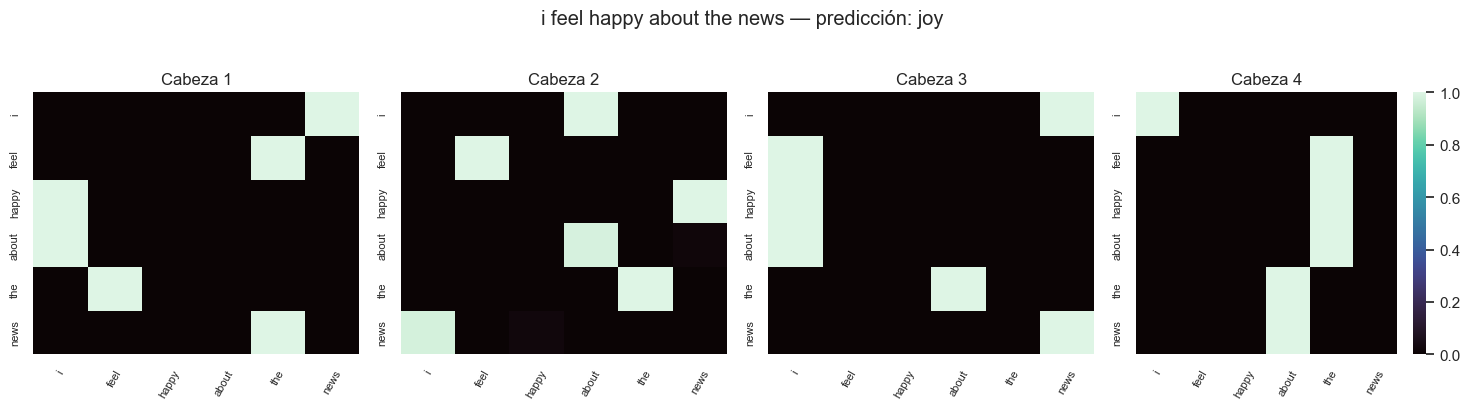

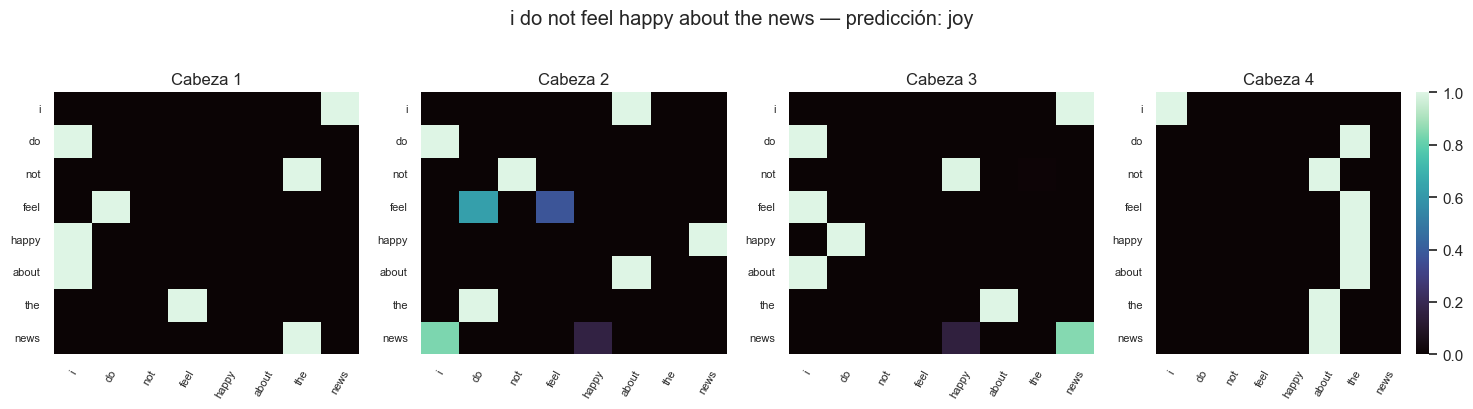

In [23]:
transformer_sinusoid = small_models['Transformer sinusoidal'].to(device).eval()
mlp_baseline = small_models['MLP'].to(device).eval()
pairs = ['i feel happy about the news', 'i do not feel happy about the news',
         'i feel afraid of the exam', 'i do not feel afraid of the exam']
rows = []
for text in pairs:
    encoded = emotion_tokenizer(text, return_tensors='pt', padding='max_length', truncation=True,
                                max_length=MAX_LEN).to(device)
    row = {'Texto': text}
    for name, model in [('MLP', mlp_baseline), ('Transformer', transformer_sinusoid)]:
        with torch.no_grad():
            probs = model(encoded['input_ids'], encoded['attention_mask']).softmax(-1)[0]
        index = probs.argmax().item()
        row[name] = id2label[index]
        row[f'Probabilidad {name}'] = probs[index].item()
    rows.append(row)
negation_results = pd.DataFrame(rows)
display(negation_results.round(3))

def plot_attention(text):
    encoded = emotion_tokenizer(text, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(device)
    with torch.no_grad():
        logits, weights = transformer_sinusoid(encoded['input_ids'], encoded['attention_mask'], True)
    tokens = [emotion_tokenizer.decode([i]).strip() for i in encoded['input_ids'][0].tolist()]
    fig, axes = plt.subplots(1, 4, figsize=(15, 4))
    for h, ax in enumerate(axes):
        sns.heatmap(weights[0][0, h].cpu().numpy(), ax=ax, cmap='mako', vmin=0, vmax=1,
                    xticklabels=tokens, yticklabels=tokens, cbar=(h == 3))
        ax.set_title(f'Cabeza {h + 1}')
        ax.tick_params(axis='x', rotation=60, labelsize=8)
        ax.tick_params(axis='y', labelsize=8)
    fig.suptitle(f'{text} — predicción: {id2label[logits.argmax(-1).item()]}', y=1.02)
    plt.tight_layout()
    plt.show()

plot_attention(pairs[0])
plot_attention(pairs[1])
mlp_baseline.cpu()
transformer_sinusoid.cpu()
release_memory()

**Resultado de la prueba de negación.** En los dos pares, tanto el MLP como el Transformer mantienen la misma emoción al agregar `not`: alegría en el primero y miedo en el segundo. Las probabilidades siguen siendo altas. Esta prueba no respalda afirmar que el Transformer entrenado desde cero maneja bien las negaciones. Los mapas cambian entre cabezas, pero no demuestran por sí solos comprensión de la negación ni una función lingüística fija para cada cabeza.

## 11. Demo de clasificación
La demo utiliza el modelo elegido por validación. Se puede cambiar el texto de la última línea para probar otra frase **en inglés**. Las barras son probabilidades producidas por el modelo; no son una garantía de acierto y no se ha evaluado su calibración.

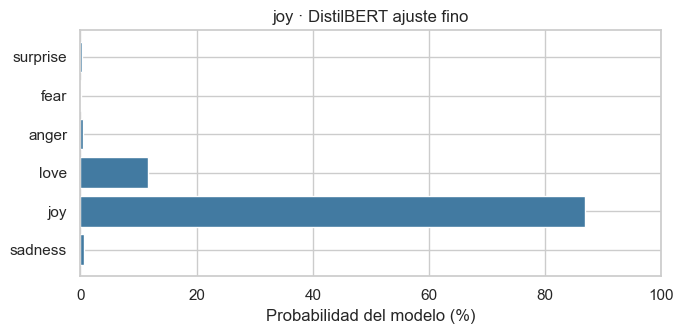

joy         0.868884
love        0.115707
sadness     0.006186
anger       0.005038
surprise    0.002516
fear        0.001669
Name: Probabilidad, dtype: float32

In [24]:
if selected_name in small_models:
    demo_model = small_models[selected_name].to(device).eval()
    demo_tokenizer = emotion_tokenizer
    demo_is_hf = False
else:
    demo_model = AutoModelForSequenceClassification.from_pretrained(hf_paths[selected_name]).to(device).eval()
    demo_tokenizer = hf_tokenizer
    demo_is_hf = True

def predict_emotion(text):
    if not isinstance(text, str) or not text.strip():
        raise ValueError('Escribe una frase en inglés.')
    encoded = demo_tokenizer(text, return_tensors='pt', padding='max_length',
                             truncation=True, max_length=MAX_LEN).to(device)
    with torch.no_grad():
        logits = demo_model(**encoded).logits if demo_is_hf else demo_model(encoded['input_ids'], encoded['attention_mask'])
        probs = logits.softmax(-1)[0].cpu().numpy()
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.barh(target_names, probs * 100, color='#427aa1')
    ax.set(xlim=(0, 100), xlabel='Probabilidad del modelo (%)', title=f'{id2label[int(probs.argmax())]} · {selected_name}')
    plt.tight_layout()
    plt.show()
    return pd.Series(probs, index=target_names, name='Probabilidad').sort_values(ascending=False)

predict_emotion('i am grateful for the support of my friends')

## 12. Conclusiones
El siguiente resumen usa las variables de esta ejecución para mantener las cifras alineadas con las tablas. Las diferencias se expresan en puntos porcentuales. La comparación describe este corpus, estas configuraciones y este presupuesto de entrenamiento; no establece que una arquitectura siempre sea superior.

In [25]:
mlp_row = comparison.loc['MLP']
tf_row = comparison.loc['Transformer sinusoidal']
frozen_row = comparison.loc['DistilBERT base congelada']
fine_row = comparison.loc['DistilBERT ajuste fino']
position_delta = validation_summary.loc['Transformer sinusoidal', 'mean'] - validation_summary.loc['Transformer posiciones aprendibles', 'mean']
selected_row = comparison.loc[selected_name]
worst_class = class_reports[selected_name]['f1-score'].idxmin()
best_class = class_reports[selected_name]['f1-score'].idxmax()

display(Markdown(f'''
1. **Comparación con el MLP.** El MLP obtuvo {mlp_row['Exactitud prueba']:.2%} de exactitud y {mlp_row['Macro F1 prueba']:.2%} de Macro F1. El Transformer sinusoidal obtuvo {tf_row['Exactitud prueba']:.2%} y {tf_row['Macro F1 prueba']:.2%}, respectivamente. La diferencia Transformer menos MLP fue de {(tf_row['Exactitud prueba']-mlp_row['Exactitud prueba'])*100:+.2f} puntos en exactitud y {(tf_row['Macro F1 prueba']-mlp_row['Macro F1 prueba'])*100:+.2f} puntos en Macro F1. Entrenaron durante {mlp_row['Tiempo entrenamiento (s)']:.1f} y {tf_row['Tiempo entrenamiento (s)']:.1f} segundos. La utilidad de la atención debe valorarse junto con ese costo.

2. **Codificación de posición.** En tres semillas, la diferencia media de Macro F1 de validación entre posiciones sinusoidales y aprendibles fue de {position_delta*100:+.2f} puntos. La tabla de validación muestra la dispersión. Esta comparación no demuestra que una opción sea mejor para todos los problemas.

3. **Preentrenamiento y ajuste fino.** DistilBERT con base congelada obtuvo {frozen_row['Macro F1 prueba']:.2%} de Macro F1 en prueba y el ajuste fino obtuvo {fine_row['Macro F1 prueba']:.2%}. La diferencia fue de {(fine_row['Macro F1 prueba']-frozen_row['Macro F1 prueba'])*100:+.2f} puntos. La primera opción entrenó {int(frozen_row['Parámetros entrenables']):,} parámetros; la segunda, {int(fine_row['Parámetros entrenables']):,}. Sus tiempos fueron {frozen_row['Tiempo entrenamiento (s)']:.1f} y {fine_row['Tiempo entrenamiento (s)']:.1f} segundos.

4. **Elección para la demo.** Por Macro F1 de validación elegimos **{selected_name}**. En prueba obtuvo {selected_row['Macro F1 prueba']:.2%} de Macro F1. Su mejor F1 por emoción correspondió a **{best_class}** ({class_reports[selected_name].loc[best_class, 'f1-score']:.2%}) y el menor a **{worst_class}** ({class_reports[selected_name].loc[worst_class, 'f1-score']:.2%}). El resultado global no resume por completo la dificultad de cada emoción.

5. **Límites.** La prueba de negaciones y los errores muestran casos concretos que requieren interpretación. Los mapas de atención ayudan a explorar patrones, pero no explican por sí solos la decisión. Repetimos los modelos pequeños con tres semillas; DistilBERT se evaluó con una sola semilla por su mayor costo. No medimos significancia estadística ni rendimiento fuera del corpus. Los resultados nuevos sustituyen los de la versión anterior porque cambiaron la depuración, el tokenizador y el encoder.
'''))


1. **Comparación con el MLP.** El MLP obtuvo 80.11% de exactitud y 72.88% de Macro F1. El Transformer sinusoidal obtuvo 86.00% y 82.36%, respectivamente. La diferencia Transformer menos MLP fue de +5.89 puntos en exactitud y +9.48 puntos en Macro F1. Entrenaron durante 15.3 y 39.6 segundos. La utilidad de la atención debe valorarse junto con ese costo.

2. **Codificación de posición.** En tres semillas, la diferencia media de Macro F1 de validación entre posiciones sinusoidales y aprendibles fue de -0.15 puntos. La tabla de validación muestra la dispersión. Esta comparación no demuestra que una opción sea mejor para todos los problemas.

3. **Preentrenamiento y ajuste fino.** DistilBERT con base congelada obtuvo 40.44% de Macro F1 en prueba y el ajuste fino obtuvo 88.01%. La diferencia fue de +47.57 puntos. La primera opción entrenó 595,206 parámetros; la segunda, 66,958,086. Sus tiempos fueron 154.2 y 708.6 segundos.

4. **Elección para la demo.** Por Macro F1 de validación elegimos **DistilBERT ajuste fino**. En prueba obtuvo 88.01% de Macro F1. Su mejor F1 por emoción correspondió a **sadness** (96.05%) y el menor a **surprise** (73.17%). El resultado global no resume por completo la dificultad de cada emoción.

5. **Límites.** La prueba de negaciones y los errores muestran casos concretos que requieren interpretación. Los mapas de atención ayudan a explorar patrones, pero no explican por sí solos la decisión. Repetimos los modelos pequeños con tres semillas; DistilBERT se evaluó con una sola semilla por su mayor costo. No medimos significancia estadística ni rendimiento fuera del corpus. Los resultados nuevos sustituyen los de la versión anterior porque cambiaron la depuración, el tokenizador y el encoder.


## 13. Referencias
- [Corpus de emociones y descripción de sus etiquetas](https://huggingface.co/datasets/dair-ai/emotion).
- [Attention Is All You Need](https://arxiv.org/abs/1706.03762): componentes del Transformer. El artículo reporta resultados similares entre posiciones sinusoidales y aprendibles en su experimento.
- [DistilBERT base uncased](https://huggingface.co/distilbert/distilbert-base-uncased): modelo preentrenado en inglés.
- [Trainer de Hugging Face](https://huggingface.co/docs/transformers/v4.57.1/en/main_classes/trainer).
- [Attention is not Explanation](https://aclanthology.org/N19-1357/): límites de interpretar los pesos de atención como explicaciones.
